# Getting started with CASToR

We use CASToR to reconstruct our coincidence data into images (3d matrices of voxels). CASToR operates on a maximum likelihood expectation maximization (MLEM) algorithm, which iterates over the data and calculates likely parameters, in our case voxel intensities, similar conceptually to linear regression. This way of reconstruction is standard in the industry, so it's important to know at minimum how to use this tool! Here is a tutorial for our CASToR workflow.

You will need to download and build CASToR following the general documentation:
https://castor-project.org/sites/castor-project.org/files/2024-10/CASToR_general_documentation.pdf

The download can be found here (sometimes the download links on this site don't work, contact us if issues):
https://castor-project.org/download

This might as well be the hardest part, since you're gonna have to deal with cmake and the process is different for every operating system. There are walkthroughs online, and you can ask one of us for help.

After you've built the castor-recon executible, you need 4 more files before you can properly call it, these are:
1. .lut - look up table containing coordinates and orientations of crystals in our scanner
2. .hscan - header file containing metadata about the lut
3. .cdf - binary format of data, keeps [Time, TOF, IDL, IDR]
4. .cdh - header file containing metadata about the cdf

The data file that we'll use is the 1_points_run2_HighInt_5min_coinc.dat file, which is pretty large so you can delete it after you're done (also delete cdf and cdh files). You will also need to download the TPPT_scanner_map_adjusted.csv, this you can keep since a lot of our analysis requires it. 

In [1]:
# Imports
import numpy as np
import pandas as pd
import os
import subprocess
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

In [2]:
# You will need to specify the following paths, examples of mine are shown.

geometry_file = '/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv' # csv file with crystal coordinates
config_dir = '/home/kale-chen/Documents/CASToR/castor_v3.2/config/scanner/' # use the /config/scanner/ directory in your CASToR installation
castor_dir = '/home/kale-chen/Documents/CASToR/castor_v3.2/build/' # directory of the castor-recon executable

data_file = '/home/kale-chen/Downloads/1_points_run2_HighInt_5min_coinc.dat' # coinc.dat file
name = '1_points_run2_HighInt_5min_coinc' # name of the run to use in outputs
output_dir = '/home/kale-chen/Documents/CASToR/images/' # directory to save outputs


In [3]:
# Function for making writing look up table
def geometry_to_lut():
    # Read geometry file as np array
    scanner_geometry = np.asarray(pd.read_csv(geometry_file, dtype='float32', delimiter=',', header=None))
    # Write file to scanner config directory
    try:
        scanner_geometry.tofile(os.path.join(config_dir, 'TPPT.lut'))
        print(f"LUT file written to {os.path.join(config_dir, 'TPPT.lut')}")
    except Exception as e:
        print(f"Error writing LUT file: {e}")

In [4]:
# Function for writing the hscan file
def write_hscan():
    # manually write hscan file to scanner config directory
    try:
        with open(os.path.join(config_dir, 'TPPT.hscan'), 'w') as f:
            f.write('scanner name: TPPT\n' +
            'modality:    PET\n' +
            'description: This scanner description is based on an actual scanner, however, this implementation is not supported nor validated by its manufacturer.\n' +
            'scanner radius:    ' + '167.5' + '\n' +
            'number of rings in scanner:    32\n' +
            'number of elements:    6144\n' +
            'number of layers:    1\n' +
            'number of crystals in layer(s):   6144\n' +
            'crystals size depth:    15\n' +
            'crystals size transaxial:    3.00\n' +
            'crystals size axial:    3.00\n' +
            'voxels number transaxial:    256\n' +
            'voxels number axial:    128\n' + 
            'field of view transaxial:    4000\n' +
            'field of view axial:    4000\n' +
            'min angle difference:    0' )
        print(f"Hscan file written to {os.path.join(config_dir, 'TPPT.hscan')}")
    except Exception as e:
        print(f"Error writing hscan file: {e}")

In [38]:
# Function for writing cdf

# We will typically apply a photopeak cut to the data so that we are only reconstructing on photopeak events. For demonstration, we will skip this step.

def make_cdf(name):
    try:
        # Delete existing cdf file
        if os.path.exists(os.path.join(output_dir, name) + '.cdf'):
            os.remove(os.path.join(output_dir, name) + '.cdf')
        # Chunked read
        for chunk in tqdm(pd.read_csv(data_file, sep = '\t', chunksize = 1000000, usecols = [2, 4, 7, 9], header = None)):
            chunk.columns = ['TimeL', 'IDL', 'TimeR', 'IDR']
            chunk['TimeDiff'] = chunk['TimeL'] - chunk['TimeR'] # Calculate time of flight
            chunk['IDL'] = (chunk['IDL'] - 131072) % 3072 + 3072 # Convert IDL to lut form
            chunk['IDR'] = chunk['IDR'] % 3072 # Convert IDR to lut form
            chunk['TimeL'] = chunk['TimeL'] // 1000000000000
            chunk = chunk[['TimeL', 'IDL', 'IDR', 'TimeDiff']] # Keep needed columns
            #print(chunk)
            # Process into cdf format: (Time, TOF, IDL, IDR)
            
            chunk = np.asarray(chunk, dtype = np.int32)
            towrite = np.zeros((len(chunk), 4), dtype = np.int32) # For reordering
            towrite[:,[0,1,2,3]] = chunk[:,[0,3,1,2]] # Reorder columns
            #print(towrite)
            with open(os.path.join(output_dir, name) + '.cdf', 'ab') as f:
                towrite.tofile(f)
            #break
        print(f"CDF file written to {os.path.join(output_dir, name) + '.cdf'}")
        return os.path.getsize(os.path.join(output_dir, name) + '.cdf') // 16

    except Exception as e:
        print(f"Error occurred during cdf creation: {e}")

In [6]:
# Function for writing cdh
def make_cdh(name, num_conic, tof=60):
    try:
        with open(os.path.join(output_dir, f'{name}.cdh'), 'w') as f:
            f.write('Data filename: ' + name + '.cdf\n' +
            'Number of events: '+  str(num_conic) + '\n' +
            'Data mode: list-mode\n' +
            'Data type: PET\n' +
            'Start time (s):0\n' +
            'Duration (s): ' + str(tof) + '\n' +
            'Scanner name: TPPT\n' +
            'TOF information flag: 1\n' +
            'TOF resolution (ps): 20000\n' +
            'List TOF measurement range (ps): 20000.\n'
            'Attenuation correction flag: 0\n'
            'Normalization correction flag: 0\n'
            'Scatter correction flag: 0\n'
            'Random correction flag: 0')
        print(f"CDH file written to {os.path.join(output_dir, f'{name}.cdh')}")
    except Exception as e:
        print(f"Error occurred during cdh creation: {e}")

In [36]:
# Function to call castor-recon command
def castor_recon(coinc_file_name, post, psf):
    os.chdir(output_dir)
    start = time.time()
    subprocess.run(['castor-recon',
                    '-df', os.path.join(output_dir, coinc_file_name + '.cdh'),
                    '-dout', coinc_file_name,
                    '-vb' , '2',
                    '-it', '1:16', 
                    '-conv', psf + '::psf', 
                    '-conv', post + '::post', 
                    '-vox', '1.5,1.5,1.5', 
                    '-dim', '180,180,80'
                    # 'opt'
                    # '-frm', frames,
                    ])
    print('Time for reconstruction: ' + str(time.time() - start))

In [39]:
# Run the workflow, this will take a few minutes, if you notice we are using 1 iteration
# with 16 steps each for the reconstruction, we will typically use many more iterations,
# but for demonstration we'll just use 1. If you want to know more about any of these
# files or the settings used, you can look at the documentation. In practice, it takes
# some experimentation to determine the best settings for reconstruction.

geometry_to_lut()
write_hscan()
try:
    os.mkdir(output_dir)
    print(f"Directory for storing figures for this run created: {output_dir}")
except FileExistsError:
    print("The directory for storing figures for this run already exists")
num_coinc = make_cdf(name)
make_cdh(name, num_coinc)

castor_recon(name, f'gaussian,1.5,1.5,1.75',f'gaussian,1.5,1.5,1.75')

LUT file written to /home/kale-chen/Documents/CASToR/castor_v3.2/config/scanner/TPPT.lut
Hscan file written to /home/kale-chen/Documents/CASToR/castor_v3.2/config/scanner/TPPT.hscan
The directory for storing figures for this run already exists


0it [00:00, ?it/s]

106it [00:31,  3.34it/s]


CDF file written to /home/kale-chen/Documents/CASToR/images/1_points_run2_HighInt_5min_coinc.cdf
CDH file written to /home/kale-chen/Documents/CASToR/images/1_points_run2_HighInt_5min_coinc.cdh
sOutputManager::InitOutputDirectory() -> Output path is '1_points_run2_HighInt_5min_coinc'
castor-recon() -> Launch reconstruction from CASToR version 3.2.1.
sScannerManager::BuildScannerObject() -> Start building
sScannerManager::InstantiateScanner() -> Instantiate the scanner geometry structure
iScannerPET::Instantiate() -> Create scanner structure and read parameters from configuration file
sScannerManager::GetGeometricInfoFromDataFile() -> Look for acquisition specific settings into datafile header
sScannerManager::BuildLUT() -> Generate the geometric Look-Up Table
iScannerPET::BuildLUT() -> Build LUT for scanner elements coordinates and orientations
sScannerManager::Initialize() -> From scanner TPPT
iScannerPET::Initialize() -> Initialize remaining stuff for scanner to be ready
oImageDimens

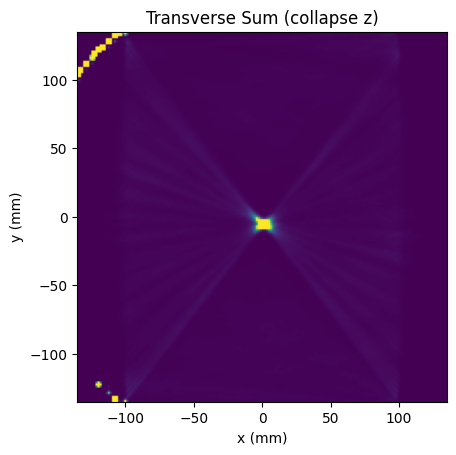

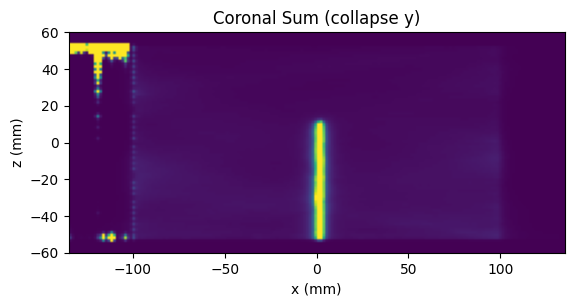

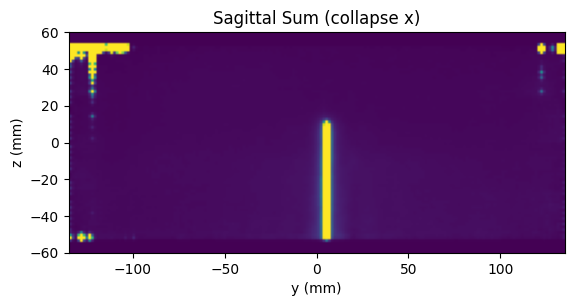

In [42]:
# Reconstruction viewer

# There are lots of ways to view reconstructed images. Here are the transverse,
# coronal, and sagittal collapses. 

img_path = os.path.join(output_dir, name, f'{name}_it1.img')

dim = (180, 180, 80)
vox = (1.5, 1.5, 1.5)

# Define bounds for use in histogramming/heatmapping
xlower, xupper = -dim[0] * vox[0] / 2, dim[0] * vox[0] / 2
ylower, yupper = -dim[1] * vox[1] / 2, dim[1] * vox[1] / 2
zlower, zupper = -dim[2] * vox[2] / 2, dim[2] * vox[2] / 2

maxthresh = 1 # Scales intensity below maxthresh to 0-1, above maxthresh becomes 1
def applythresh(img2d):
    img2d = img2d * (1 / maxthresh)
    for i in range(len(img2d)):
        for j in range(len(img2d[i])):
            if img2d[i][j] > 1:
                img2d[i][j] = 1
    return img2d

# Matplotlib histograms, these collapse the image into 2D planes showing activity of the 
# projection of the 3D image onto the plane.
img = np.fromfile(img_path, dtype = np.float32).reshape(dim, order = 'F') # Fortran order
colormap = 'viridis'

# Transverse (xy)
fig = plt.figure(0)
axxyhm = fig.add_subplot() # Heatmap
imgxy = applythresh(img.sum(axis = 2)) # Image with threshold cast
xyhm = axxyhm.imshow(imgxy.T, cmap=colormap, extent=(xlower, xupper, ylower, yupper), vmin = 0, vmax = 1) # Display heatmap
axxyhm.set_xlim(xlower, xupper) 
axxyhm.set_ylim(ylower, yupper)
axxyhm.set_xlabel("x (mm)")
axxyhm.set_ylabel("y (mm)")
axxyhm.set_title('Transverse Sum (collapse z)')

# Coronal (xz)
fig = plt.figure(1)
axxzhm = fig.add_subplot() # Heatmap
imgxz = applythresh(img.sum(axis = 1)) # Image with threshold cast
xzhm = axxzhm.imshow(imgxz.T, cmap=colormap, extent=(xlower, xupper, zlower, zupper), vmin = 0, vmax = 1) # Display heatmap
axxzhm.set_xlim(xlower, xupper) 
axxzhm.set_ylim(zlower, zupper)
axxzhm.set_xlabel("x (mm)")
axxzhm.set_ylabel("z (mm)")
axxzhm.set_title('Coronal Sum (collapse y)')

# Sagittal (yz)
fig = plt.figure(2)
axyzhm = fig.add_subplot() # Heatmap
imgyz = applythresh(img.sum(axis = 0)) # Image with threshold cast
yzhm = axyzhm.imshow(imgyz.T, cmap=colormap, extent=(ylower, yupper, zlower, zupper), vmin = 0, vmax = 1) # Display heatmap
axyzhm.set_xlim(ylower, yupper) 
axyzhm.set_ylim(zlower, zupper)
axyzhm.set_xlabel("y (mm)")
axyzhm.set_ylabel("z (mm)")
axyzhm.set_title('Sagittal Sum (collapse x)')

plt.show()


From the reconstruction you should see a line source with some noise on the edges of the field of view.

### Exercise: resolution
We are often interested in the resolution of our images, we usually have the worst resolution along the direction of the LORs, which you can see by comparing the coronal and sagital views.

For this exercise, calculate a rough estimate of the resolution of this line source in both the x and y directions, and verify that our resolution in x direction appears worse. Think about why this makes sense. 


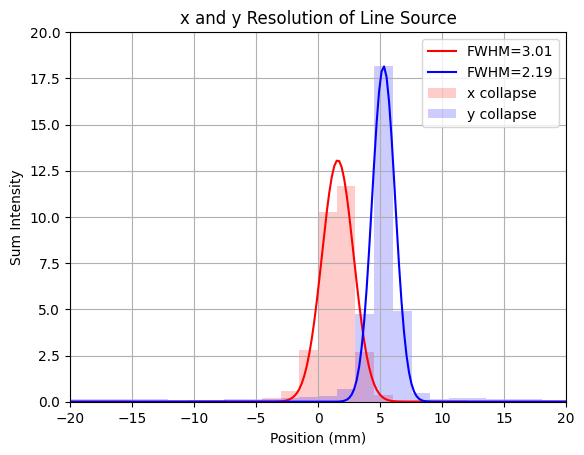

In [ ]:
# Exercise: resolution, outline given, fill in TODOs and Nones
from scipy.optimize import curve_fit

def gaussian(x, a, mu, sig):
    # TODO: implement gaussian function
    return a * np.exp(-(x - mu)**2 / (2 * sig**2))

# To obtain the intensities along the x axis, you need to collapse the image along the y and z axis, 
# As an example, the viewer code does this img.sum(axis = 2), which collapses along the y axis.
transverse_intensities = img.sum(axis = 2)
x_intensities = None
y_intensities = None
# You will also need coordinates for the x and y data, use np.linspace on the lower and upper bounds of the image
x_coords = None
y_coords = None
# Plot the intensities using plt.bar
plt.bar(x_coords, x_intensities)
plt.bar(y_coords, y_intensities)
# To get the resolution, we need to fit the gaussian to the intensities, 
# then take the resolution to be the full width at half maximum (FWHM) of the gaussian,
# which you can calculate by multiplying the standard deviation by 2 * sqrt(2 * ln(2)) = 2.355
popt1, pcov1 = None
plt.plot(x_coords, gaussian(x_coords, *popt1))
popt2, pcov2 = None
plt.plot(y_coords, gaussian(y_coords, *popt2))

# Isolate the line source near the center of the image, there's a lot of noise that we want to cut out to see our resolution better
# Do this with plt.xlim and plt.ylim
plt.xlim(None, None)
plt.ylim(None, None)
plt.grid() # Shows grid
plt.legend() # Shows legend
plt.title(None) # Add appropriate title
plt.ylabel(None) # Add appropriate y-axis label
plt.xlabel(None) # Add appropriate x-axis label
plt.show()



